In [81]:
import pandas as pd
import networkx as nx
import json
from collections import defaultdict
import community.community_louvain as community_louvain
from matplotlib import pyplot as plt
import numpy as np
import random
import itertools



In [27]:
def represent_degree_distribution(G,node_list,scale='linear',rep='bars', title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_xlabel('Degree',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15) 
    ax.set_title(title)

In [26]:
def fit_CCDF(G,node_list, title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel('$k$',fontsize=15)
    ax.set_ylabel('$CCDF(k)$',fontsize=15)

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()
    ax.set_title(title)

In [ ]:
# =========================================================
# LOAD JSON
# =========================================================

with open(
    "./doi_10_5061_dryad_dr7sqv9v8__v20200626/"
    "NJC19_network_data_and_code/"
    "NJC19_network.json"
) as f:

    data = json.load(f)

# =========================================================
# CREATE DIRECTED BIPARTITE MULTIGRAPH
# =========================================================
#
# WHY MultiDiGraph?
#
# - Multi:
#   same species/metabolite pair can have
#   multiple interaction types
#
# - Di:
#   direction represents metabolic flow
#
# - Bipartite:
#   species and metabolites are separate node sets
#
# =========================================================

B = nx.MultiDiGraph()

# =========================================================
# ACTIVITY CLASSIFICATION
# =========================================================

activity_map = {

    "Consumption (import)": {
        "category": "import",
        "sign": 1
    },

    "Production (export)": {
        "category": "export",
        "sign": 1
    },

    "Consumption (import), Production (export)": {
        "category": "exchange",
        "sign": 1
    },

    "Macromolecule degradation": {
        "category": "degradation",
        "sign": 1
    },

    "Consumption (import) (-)": {
        "category": "import",
        "sign": -1
    },

    "Production (export) (-)": {
        "category": "export",
        "sign": -1
    },

    "Macromolecule degradation (-)": {
        "category": "degradation",
        "sign": -1
    }
}

# =========================================================
# BUILD NETWORK
# =========================================================

for interaction_id, interaction in data.items():

    # -----------------------------------------------------
    # Extract fields
    # -----------------------------------------------------

    species = interaction["Species"].strip().lower()

    metabolite = interaction[
        "Small-molecule metabolite or macromolecule"
    ].strip().lower()

    activity = interaction["Metabolic activity"]

    refs = interaction["Ref. #"]

    # -----------------------------------------------------
    # Parse activity metadata
    # -----------------------------------------------------

    parsed = activity_map[activity]

    category = parsed["category"]
    sign = parsed["sign"]

    # -----------------------------------------------------
    # Add species node
    # -----------------------------------------------------

    B.add_node(
        species,

        bipartite=0,
        node_type="species",

        label=species
    )

    # -----------------------------------------------------
    # Add metabolite node
    # -----------------------------------------------------

    B.add_node(
        metabolite,

        bipartite=1,
        node_type="metabolite",

        label=metabolite
    )

    # =====================================================
    # DEFINE EDGE DIRECTION
    # =====================================================
    #
    # IMPORT:
    # metabolite -> species
    #
    # EXPORT:
    # species -> metabolite
    #
    # EXCHANGE:
    # both directions
    #
    # DEGRADATION:
    # metabolite -> species
    #
    # =====================================================

    # -----------------------------------------------------
    # IMPORT
    # -----------------------------------------------------

    if category == "import":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXPORT
    # -----------------------------------------------------

    elif category == "export":

        B.add_edge(
            species,
            metabolite,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXCHANGE
    # -----------------------------------------------------

    elif category == "exchange":

        # species exports metabolite
        B.add_edge(
            species,
            metabolite,

            interaction_id=f"{interaction_id}_export",

            activity=activity,
            category="export",

            sign=sign,

            refs=refs
        )

        # species imports metabolite
        B.add_edge(
            metabolite,
            species,

            interaction_id=f"{interaction_id}_import",

            activity=activity,
            category="import",

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # DEGRADATION
    # -----------------------------------------------------

    elif category == "degradation":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

# =========================================================
# BASIC SUMMARY
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 1
]

print("=" * 60)
print("DIRECTED BIPARTITE METABOLIC NETWORK")
print("=" * 60)

print(f"Total nodes: {B.number_of_nodes()}")
print(f"Total edges: {B.number_of_edges()}")

print()

print(f"Species nodes: {len(species_nodes)}")
print(f"Metabolite nodes: {len(metabolite_nodes)}")

# =========================================================
# CHECK BIPARTITE STRUCTURE
# =========================================================

is_bipartite = nx.is_bipartite(B)

print()
print(f"Is bipartite: {is_bipartite}")


# =========================================================
# EDGE CATEGORY COUNTS
# =========================================================

from collections import Counter

edge_categories = Counter()

for _, _, data in B.edges(data=True):

    edge_categories[data["category"]] += 1

print()
print("Edge categories:")

for category, count in edge_categories.items():

    print(f"  {category}: {count}")

# =========================================================
# OPTIONAL:
# SHOW EXAMPLE EDGES
# =========================================================

print()
print("=" * 60)
print("EXAMPLE EDGES")
print("=" * 60)

for i, (u, v, d) in enumerate(B.edges(data=True)):

    print(
        f"{u} -> {v} | "
        f"{d['category']} | "
        f"sign={d['sign']}"
    )

    if i >= 9:
        break

DIRECTED BIPARTITE METABOLIC NETWORK
Total nodes: 1127
Total edges: 9316

Species nodes: 844
Metabolite nodes: 283

Is bipartite: True

Edge categories:
  export: 3041
  import: 5798
  degradation: 477

EXAMPLE EDGES
absiella dolichum -> acetate | export | sign=1
absiella dolichum -> butyrate | export | sign=1
absiella dolichum -> h2s (hs-) | export | sign=-1
absiella dolichum -> l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate) | export | sign=1
absiella dolichum -> nh3 (ammonia, nh4+, ammonium) | export | sign=1
absiella dolichum -> pyruvate | export | sign=1
absiella dolichum -> succinate | export | sign=1
acetate -> actinosynnema mirum | import | sign=-1
acetate -> alicycliphilus denitrificans | import | sign=1
acetate -> anaerobutyricum hallii | import | sign=1


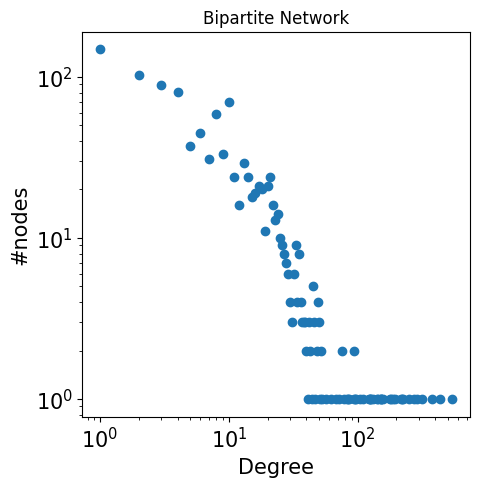

In [28]:
represent_degree_distribution(B,node_list=B.nodes(),scale='log',rep='scatter', title='Bipartite Network') ## Represent the degree distribution of the graph with a scatter plot and log scale


/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_86736/1294712512.py:20: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


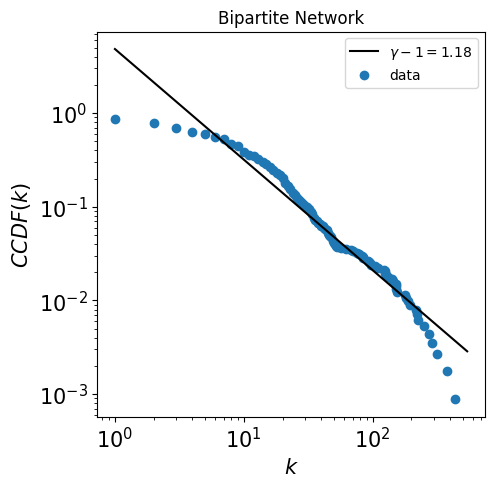

In [29]:
fit_CCDF(B,node_list=B.nodes(), title='Bipartite Network') ## Fit the CCDF of the degree distribution with a power law and represent it in a log-log scale

Species table

Here we identify

generalist bacteria (high degree)
specialists (low degree)

Metabolite table

You will identify:

hub metabolites (used by many species)
rare metabolites (specialized compounds)

In [19]:
# =========================================================
# ASSUMPTION:
# B is already built and contains:
# - species nodes (bipartite=0)
# - metabolite nodes (bipartite=1)
# - directed edges species ↔ metabolites
# =========================================================

# =========================================================
# SPLIT NODES BY TYPE
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

# =========================================================
# DEGREE CALCULATION FUNCTIONS
# =========================================================
#
# In a directed bipartite metabolic network:
# - degree = total interactions (in + out)
# - in-degree = what comes into node
# - out-degree = what leaves node
#
# =========================================================

def compute_degrees(G, nodes):

    results = []

    for n in nodes:

        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)
        total = indeg + outdeg

        results.append({
            "node": n,
            "in_degree": indeg,
            "out_degree": outdeg,
            "total_degree": total
        })

    return pd.DataFrame(results)

# =========================================================
# SPECIES DEGREE ANALYSIS
# =========================================================

species_df = compute_degrees(B, species_nodes)
species_df = species_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP SPECIES BY DEGREE")
print("="*60)
print(species_df.head(20))

# =========================================================
# METABOLITE DEGREE ANALYSIS
# =========================================================

metabolite_df = compute_degrees(B, metabolite_nodes)
metabolite_df = metabolite_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP METABOLITES BY DEGREE")
print("="*60)
print(metabolite_df.head(20))

# =========================================================
# OPTIONAL: SAVE RESULTS
# =========================================================

species_df.to_csv("species_degree_analysis.csv", index=False)
metabolite_df.to_csv("metabolite_degree_analysis.csv", index=False)

# =========================================================
# SUMMARY STATS
# =========================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nSpecies degree stats:")
print(species_df["total_degree"].describe())

print("\nMetabolite degree stats:")
print(metabolite_df["total_degree"].describe())


TOP SPECIES BY DEGREE
                             node  in_degree  out_degree  total_degree
838              human colonocyte        120           4           124
843         mouse intestinal cell         60          18            78
106  bacteroides thetaiotaomicron         47          29            76
120        bifidobacterium longum         40          22            62
116         bifidobacterium breve         38          14            52
311              escherichia coli         21          28            49
216       clostridium perfringens         30          18            48
292         enterococcus faecalis         32          15            47
115       bifidobacterium bifidum         30          16            46
97             bacteroides ovatus         31          15            46
112  bifidobacterium adolescentis         31          15            46
446       lactobacillus plantarum         31          14            45
108          bacteroides vulgatus         34          

These plots provide an aggregate, macroscopic view of your ecosystem's topology. Together, they confirm that both your **Species** and **Metabolite** layers follow a **heavy-tailed, scale-free distribution**, a structural hallmark of highly evolved biological and metabolic systems.

Here is a breakdown of what these specific visual representations and statistical exponents reveal about your data:

---

### 1. The Shape of the Data: Classic Scale-Free Topology

The second screenshot shows a classic power-law distribution ($P(k) \sim k^{-\gamma}$) plotted on a log-log scale:

* **The "Long Tail":** A massive number of nodes crowd the top-left corner (meaning the vast majority of species and metabolites have a very low degree, interacting with only 1 or 2 partners).
* **The Presence of Hyper-Hubs:** As you move to the right along the x-axis, the number of nodes drops drastically, but it extends out to rare "hyper-hubs" with degrees exceeding $10^2$ (like the human colonocyte node you discovered earlier).

### 2. CCDF vs. Direct Degree Plots

The first screenshot utilizes the **Complementary Cumulative Distribution Function (CCDF)**, defined as $P(X \ge k)$.

* **Why this plot matters:** In standard log-log degree plots (your second image), the tail gets incredibly noisy and scattered because you hit counts of single nodes ($y = 10^0$). The CCDF calculates the probability of finding a node with a degree *greater than or equal to* $k$. This effectively smooths out that tail noise, providing a far more statistically robust line for fitting a power-law exponent.

---

### 3. Interpreting the Extreme Exponents ($\gamma$)

For a standard power-law degree distribution, the CCDF scales as $k^{-(\gamma-1)}$. Based on your linear fits:

* **Species Network:** $\gamma - 1 = 0.40 \implies \gamma = 1.40$
* **Metabolite Network:** $\gamma - 1 = 0.04 \implies \gamma = 1.04$

In theoretical network science, a power-law exponent of **$\gamma < 2$** is unusual for random macroscopic networks, but it is highly characteristic of specialized biological datasets. It signifies an **extreme "rich-get-richer" (preferential attachment) architecture**:

#### The Species Network ($\gamma = 1.40$)

An exponent this low indicates an incredibly centralized ecosystem. Most bacterial species in your model are highly specialized niche players with narrow metabolic profiles (low degrees). The structural integrity and functional connectivity of the entire microbiome are pulled together by a small elite tier of multi-functional hubs that process the vast majority of shared resources.

#### The Metabolite Network ($\gamma = 1.04$)

An exponent dangerously close to $1.0$ is a classic signature of **"currency metabolites" or massive systemic sinks**.

* The line is nearly flat over a wide range of $k$, meaning the drop-off in probability is exceptionally slow.
* Biologically, this reflects the presence of universal metabolic currencies (like $\text{H}_2\text{O}$, $\text{ATP}$, $\text{NADH}$, or standard short-chain fatty acids) or major host-tissue targets. These select molecules are so globally ubiquitous in your import/export rules that they structurally dominate the network far more than any individual organism does.

---

### 4. Biological Implications: Robustness and Vulnerability

Networks with this specific scale-free topology display a property known as **error tolerance but attack vulnerability**:

* **High Robustness:** If you randomly delete species or metabolites from this system (simulating the random loss of a rare microbe due to minor environmental shifts), the overall network structure will remain completely unaffected because most nodes are peripheral.
* **Targeted Vulnerability:** Conversely, the system is highly sensitive to targeted perturbations. If an antibiotic or an environmental toxin knocks out a primary hub species, or if a critical currency metabolite pathway is blocked, the entire metabolic fabric of the network can rapidly fragment.

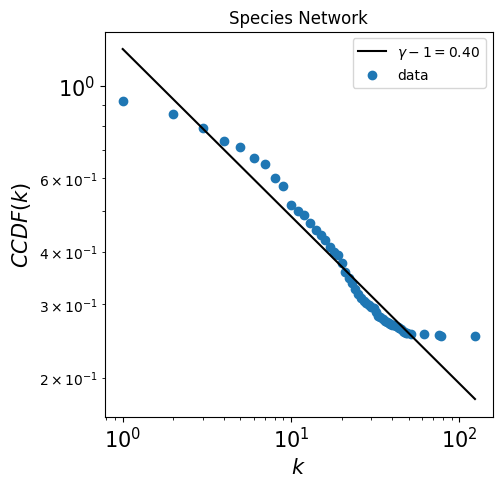

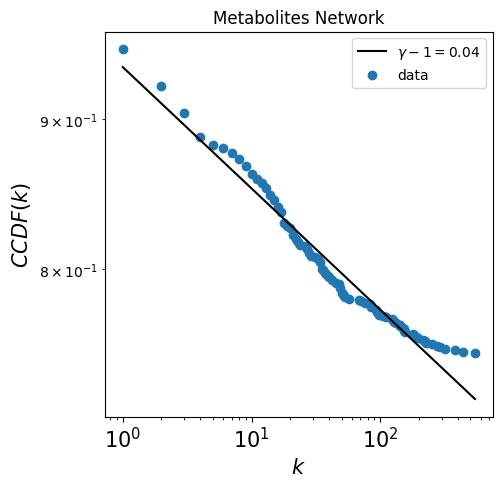

In [31]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

fit_CCDF(B, node_list=species_nodes, title='Species Network')
fit_CCDF(B, node_list=metabolite_nodes, title='Metabolites Network')

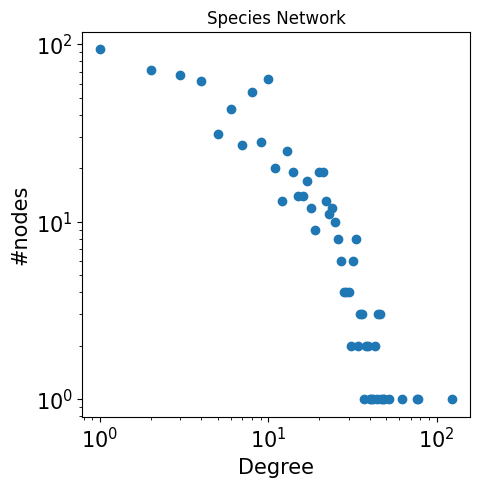

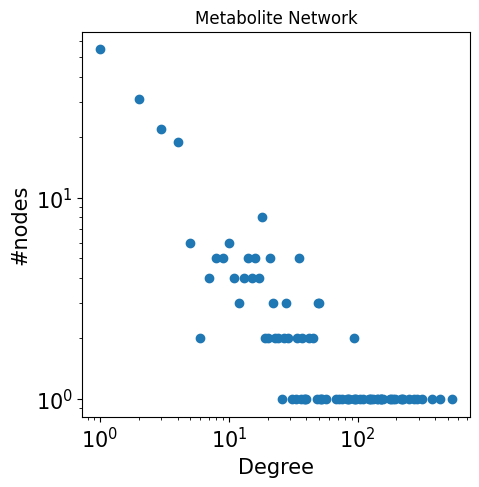

In [39]:
represent_degree_distribution(
    B,
    node_list=species_nodes,
    scale='log',
    rep='scatter',
	title='Species Network'
)

represent_degree_distribution(
    B,
    node_list=metabolite_nodes,
    scale='log',
    rep='scatter',
	title='Metabolite Network'
	
)

In [51]:
def largest_component_size(G):

    # convert to undirected for connectivity analysis
    H = G.to_undirected()

    components = list(nx.connected_components(H))

    if len(components) == 0:
        return 0

    return max(len(c) for c in components)


def attack_simulation(G, nodes, strategy="random", centrality=None, steps=50):

    G = G.copy()

    results = []

    # ---------------------------------------------
    # ranking strategy
    # ---------------------------------------------

    if strategy == "random":
        ranked = nodes.copy()

    elif strategy == "degree":
        ranked = sorted(nodes, key=lambda n: G.degree(n), reverse=True)

    elif strategy == "centrality":
        ranked = sorted(nodes, key=lambda n: centrality.get(n, 0), reverse=True)

    else:
        raise ValueError("Unknown strategy")

    # ---------------------------------------------
    # removal loop
    # ---------------------------------------------

    for i in range(steps):

        if len(ranked) == 0:
            break

        if strategy == "random":
            node = random.choice(ranked)
            ranked.remove(node)
        else:
            node = ranked.pop(0)

        if node in G:
            G.remove_node(node)

        results.append({
            "step": i,
            "LCC": largest_component_size(G)
        })

    return pd.DataFrame(results)

In [43]:
betweenness = nx.betweenness_centrality(B)

In [53]:
all_nodes = list(B.nodes())

In [54]:
random_results = attack_simulation(
    B,
    all_nodes,
    strategy="random",
    steps=50
)

In [59]:
targeted_results = attack_simulation(
    B,
    all_nodes,
    strategy="degree",
    steps=50
)

This plot is the empirical proof of the **scale-free, error-tolerant but attack-vulnerable** nature we just talked about. It visualizes exactly what happens to the structural integrity of your metabolic ecosystem when elements are systematically destroyed.

Here is the breakdown of what this robustness analysis tells us about your network:

---

### 1. The Blue Line: Impregnable to Random Failures

The blue line simulates a scenario where nodes are eliminated completely at random (e.g., random fluctuations in microbial populations, or transient environmental noise).

* **The Behavior:** The largest connected component drops incredibly slowly and smoothly. Even after losing 50 nodes, the network's giant component barely shrinks.
* **The Biological Meaning:** Your metabolic web is profoundly stable against random accidents. Because the overwhelming majority of nodes are peripheral metabolites or specialized, low-degree bacteria, picking a node at random almost guarantees you will hit a minor player. The core metabolic "superhighway" remains perfectly intact.

---

### 2. The Orange Line: Catastrophic Collapse via Targeted Attack

The orange line simulates an adversarial scenario where nodes are removed in order of their importance—starting with the highest-degree hubs first.

* **The Behavior:** The network undergoes a steep, dramatic, and jagged collapse. Removing just the top 50 hubs fragments the largest connected component, shrinking it from roughly 1,125 connected nodes down to under 750.
* **The Biological Meaning:** This is the achilles' heel of your network architecture. If an environmental stressor, a highly targeted antibiotic, or a disease state knocks out the key players, the entire systemic network shatters.

---

### 3. Connecting the Plot to Your "Top Species" Data

The very beginning of that orange curve (from 0 to 5 nodes removed) represents the immediate impact of deleting the exact nodes from your first screenshot:

1. **Nodes 0–2:** Removing the **Human Colonocyte** (124 degrees) and the **Mouse Intestinal Cell** (78 degrees). Because these host cells act as massive global sinks consuming over a hundred different metabolites, removing them instantly detaches a massive chunk of the network's structural purpose, causing the first immediate plunge in the curve.
2. **Nodes 3–5:** Removing primary metabolic drivers like ***Bacteroides thetaiotaomicron*** and ***Bifidobacterium longum***. Deleting these species breaks the critical upstream carbohydrate-degradation pathways that feed the rest of the community.

### 4. Why is the Orange Line "Jagged"? (The Step Drops)

You will notice that the orange line doesn't just decline smoothly; it drops in distinct, sharp vertical steps (for instance, right around 4, 20, 34, and 40 nodes removed).

In network science, these steps represent **cascade fragmentations**. When you delete a critical hub, you aren't just losing that single node. You are cutting the only lifeline for a whole cluster of peripheral "leaf" nodes that relied exclusively on that hub to connect to the rest of the network.

When that hub dies, an entire sub-community of specialized bacteria or unique peripheral metabolites instantly breaks off from the main component, causing the size of the remaining network to drop in sudden, massive chunks.

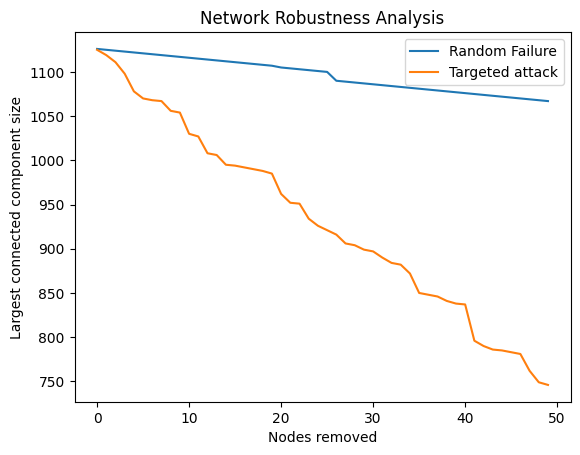

In [60]:
plt.figure()

plt.plot(random_results["step"], random_results["LCC"],
         label="Random Failure")

plt.plot(targeted_results["step"], targeted_results["LCC"],
         label="Targeted attack")

plt.xlabel("Nodes removed")
plt.ylabel("Largest connected component size")
plt.title("Network Robustness Analysis")

plt.legend()
plt.show()

In [44]:
species_attack_random = attack_simulation(
    B,
    species_nodes,
    strategy="random"
)

species_attack_degree = attack_simulation(
    B,
    species_nodes,
    strategy="degree"
)

species_attack_betweenness = attack_simulation(
    B,
    species_nodes,
    strategy="centrality",
    centrality=betweenness
)

In [45]:
metabolite_attack_random = attack_simulation(
    B,
    metabolite_nodes,
    strategy="random"
)

metabolite_attack_degree = attack_simulation(
    B,
    metabolite_nodes,
    strategy="degree"
)

metabolite_attack_betweenness = attack_simulation(
    B,
    metabolite_nodes,
    strategy="centrality",
    centrality=betweenness
)

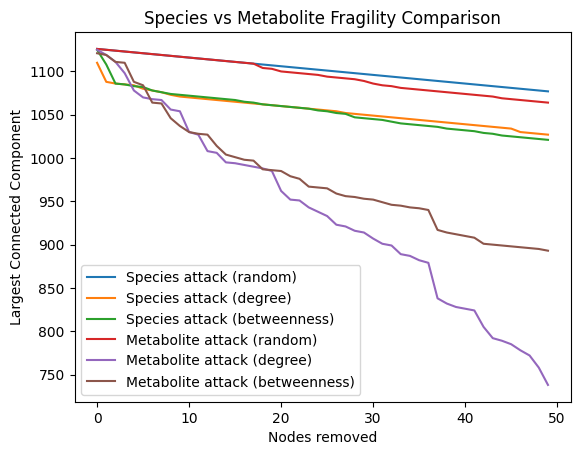

In [50]:
plt.figure()

# Species
plt.plot(species_attack_random["step"], species_attack_random["LCC"],
         label="Species attack (random)")

plt.plot(species_attack_degree["step"], species_attack_degree["LCC"],
         label="Species attack (degree)")

plt.plot(species_attack_betweenness["step"], species_attack_betweenness["LCC"],
         label="Species attack (betweenness)")

# Metabolites
plt.plot(metabolite_attack_random["step"], metabolite_attack_random["LCC"],
         label="Metabolite attack (random)")


plt.plot(metabolite_attack_degree["step"], metabolite_attack_degree["LCC"],
         label="Metabolite attack (degree)")

plt.plot(metabolite_attack_betweenness["step"], metabolite_attack_betweenness["LCC"],
         label="Metabolite attack (betweenness)")

plt.xlabel("Nodes removed")
plt.ylabel("Largest Connected Component")
plt.title("Species vs Metabolite Fragility Comparison")
plt.legend()
plt.show()

### 1. Visualizing the Matrix Anatomy

By sorting the matrix rows (Species) and columns (Metabolites) from highest degree to lowest degree, you have forced the network to reveal its underlying geometry.

* **The Vertical "Super-Highways" (Far Left Columns 0 to ~30):** Notice how the matrix forms almost solid vertical yellow lines on the left side that span from the top row all the way down to the bottom. This means a tiny handful of metabolites interact with *almost every single species* in the dataset. These are your universal currency metabolites (like water, $\text{H}^+$, or $\text{ATP}$) and major global host sinks (the metabolites being drawn in by the human colonocyte).
* **The Generalist Elite (Top Rows 0 to ~100):** The top block of rows is densely packed with yellow pixels stretching quite far to the right. These are your metabolic generalists (like *Bacteroides thetaiotaomicron*). They possess the genetic machinery to interact with a massive portfolio of both common and rare metabolites.
* **The Specialist Desert (Bottom-Right Quadrant):** As you move toward the bottom-right, the matrix becomes incredibly sparse. This represents specialist microbes interacting with rare, niche metabolites.

---

### 2. Interpreting the NODF Score (0.297)

The **NODF** (Nestedness metric based on Overlap and Distance Decreasing Fill) quantifies this layout on a scale from 0 to 1:

* **1.0** would mean a perfectly nested triangle (specialists *only* use a strict subset of what generalists use).
* **0.0** would mean completely random or anti-nested (like a diagonal line where everyone has unique niches).

Your score of **~0.30 indicates a moderate, partial nestedness**. It confirms an architectural trend toward a nested core, but explains why it isn't a perfect triangle:

#### Why is it only 0.30? (The Metabolic Reality)

If this were a classic ecological network (like bees visiting flowers), the nestedness would likely be much higher because generalist bees visit everything, and specialist bees just visit a subset of those same popular flowers.

However, in a **microbial metabolic network**, biochemistry introduces a constraint: **Niche Specificity**.
Looking closely at the sparse area (rows 400–800, columns 50–250), you can see isolated horizontal streaks and scattered yellow dots. These represent specialist bacteria utilizing specialized, unique metabolic pathways (e.g., specific carbohydrate degradation, toxin production, or methanogenesis) that even the generalist powerhouse species do not touch.

---

### Summary of the System's Architecture

Your network uses a **hybrid design** that balances efficiency and specialization:

1. **A Shared Nested Core:** A foundational layer of the microbiome revolves around a highly nested core of universal cross-feeding. Generalists break down major substrates into core currencies that almost all peripheral species rely on. This is what keeps the blue line in your robustness plot so stable.
2. **Parallel Idiosyncratic Niches:** Superimposed on that core are highly specific metabolic pathways unique to individual species. This creates the "scatter" in your matrix, keeps the NODF at a moderate 0.30, and represents the highly specialized functional diversity of the gut.

In [66]:
# ---------------------------------------------------------
# UNIQUE NODE LISTS
# ---------------------------------------------------------

species_nodes = sorted(species_nodes)
metabolite_nodes = sorted(metabolite_nodes)

# ---------------------------------------------------------
# INDEX MAPS
# ---------------------------------------------------------

species_index = {
    s: i for i, s in enumerate(species_nodes)
}

metabolite_index = {
    m: j for j, m in enumerate(metabolite_nodes)
}

# ---------------------------------------------------------
# EMPTY MATRIX
# ---------------------------------------------------------

M = np.zeros(
    (len(species_nodes), len(metabolite_nodes)),
    dtype=int
)

# ---------------------------------------------------------
# FILL MATRIX
# ---------------------------------------------------------

for u, v in B.edges():

    u_type = B.nodes[u]["node_type"]
    v_type = B.nodes[v]["node_type"]

    # species -> metabolite
    if u_type == "species":

        s = u
        m = v

    # metabolite -> species
    else:

        s = v
        m = u

    i = species_index[s]
    j = metabolite_index[m]

    M[i, j] = 1

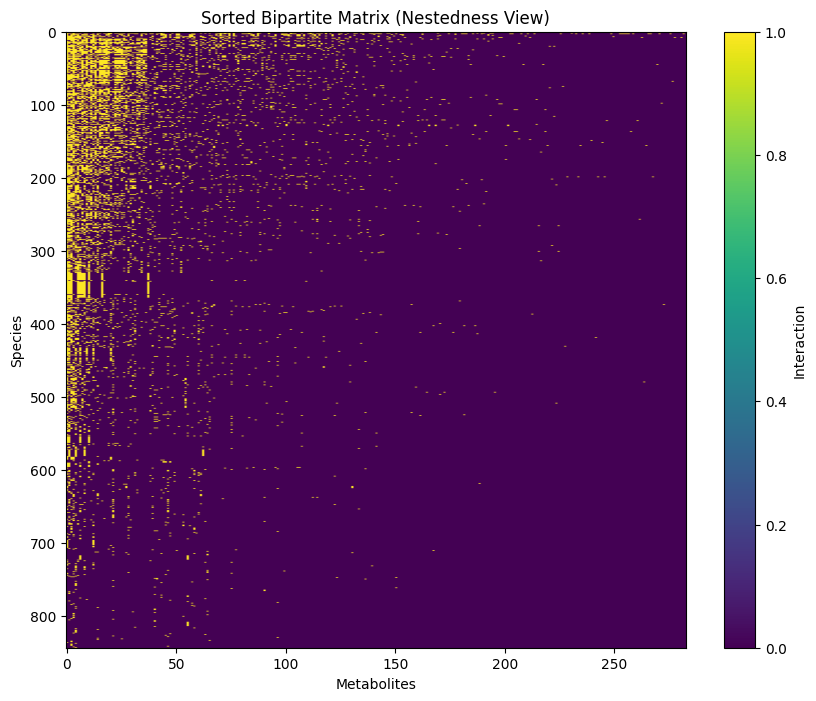

In [69]:
# ---------------------------------------------------------
# sort rows and columns by degree
# ---------------------------------------------------------

row_order = np.argsort(M.sum(axis=1))[::-1]
col_order = np.argsort(M.sum(axis=0))[::-1]

M_sorted = M[row_order][:, col_order]

# ---------------------------------------------------------
# visualize sorted matrix
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(M_sorted, aspect="auto")

plt.title("Sorted Bipartite Matrix (Nestedness View)")
plt.xlabel("Metabolites")
plt.ylabel("Species")

plt.colorbar(label="Interaction")

plt.show()

In [71]:
class NestednessCalculator(object):
    """Calculates the nestedness of the input matrix.

    The algorithms that have been implemented are:
        - NODF (Nestedness based on Overlap and Decreasing Fill)
    """
    def __init__(self, mat):
        """Initialize the Nestedness calculator and check the input matrix.

        :param mat: binary input matrix
        :type mat: numpy.array
        """
        self.check_input_matrix_is_binary(mat)
        self.check_degrees(mat)

    @staticmethod
    def check_input_matrix_is_binary(mat):
        """Check that the input matrix is binary, i.e. entries are 0 or 1.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix is not
            binary
        """
        assert np.all(np.logical_or(mat == 0, mat == 1)), \
            "Input matrix is not binary."

    @staticmethod
    def check_degrees(mat):
        """Check that rows and columns are not completely zero.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix has
            completely zero rows or columns.
        """
        assert np.all(mat.sum(axis=1) != 0), \
            "Input matrix rows with only zeros, abort."
        assert np.all(mat.sum(axis=0) != 0), \
            "Input matrix columns with only zeros, abort."

################################################################################
# NODF - Nestedness based on Overlap and Decreasing Fill
################################################################################

    def get_paired_nestedness(self, mat, rows=True):
        """Calculate the paired nestedness along the rows or columns of the.

        :param mat: binary input matrix
        :type mat: numpy.array
        :param rows: if True, pairs are calculated along the rows, if False
            along the columns
        :type rows: bool

        :returns: degree of paired nestedness
        :rtype: float

        The method uses the algorithm described in the `BiMat framework for
        MATLAB <https://bimat.github.io/alg/nestedness.html>`_.
        """
        if rows:
            # consider rows
            po_mat = np.dot(mat, mat.T)
            degrees = mat.sum(axis=1)
        else:
            # consider cols
            po_mat = np.dot(mat.T, mat)
            degrees = mat.sum(axis=0)
        assert len(degrees) == len(po_mat)

        neg_delta = (degrees != degrees[:, np.newaxis])
        deg_matrix = degrees * np.ones_like(po_mat)
        deg_minima = np.minimum(deg_matrix, deg_matrix.T)
        n_pairs = po_mat[neg_delta] / (2. * deg_minima[neg_delta])
        return n_pairs.sum()

    def nodf(self, mat):
        """Calculate the NODF nestedness of the input matrix [AlmeidaNeto]_.

        :param mat: binary input matrix
        :type mat: numpy.array

        :returns: NODF nestedness of the input matrix
        :rtype: float


        The algorithm has been tested by comparison with the `online tool
        provided at <http://ecosoft.alwaysdata.net/>`_
        """
        n_pairs_rows = self.get_paired_nestedness(mat, rows=True)
        n_pairs_cols = self.get_paired_nestedness(mat, rows=False)
        norm = np.sum(np.array(mat.shape) * (np.array(mat.shape) - 1) / 2.)
        nodf = (n_pairs_rows + n_pairs_cols) / norm
        return nodf

In [72]:

calculator = NestednessCalculator(M_sorted)

nodf = calculator.nodf(M_sorted)

print("NODF =", nodf)

NODF = 0.2977012779627041


In [ ]:
# =========================================================
# NUMBER OF EDGES (L)
# =========================================================

L = B.number_of_edges()

# =========================================================
# NUMBER OF SPECIES (S)
# =========================================================

S = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
])

# =========================================================
# NUMBER OF METABOLITES (M)
# =========================================================

M = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
])

# =========================================================
# CONNECTANCE
# =========================================================

connectance = L / (S * M)

print("=" * 60)
print("BIPARTITE CONNECTANCE")
print("=" * 60)

print(f"Species (S): {S}")
print(f"Metabolites (M): {M}")
print(f"Links (L): {L}")
print(f"Connectance (C): {connectance:.6f}")

# need to check this better

BIPARTITE CONNECTANCE
Species (S): 844
Metabolites (M): 283
Links (L): 9316
Connectance (C): 0.039003


# Competition Network

In [79]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
]

species_to_metabolites = defaultdict(set)

for u, v, d in B.edges(data=True):

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":
        species = u
        metabolite = v
    else:
        species = v
        metabolite = u

    species_to_metabolites[species].add(metabolite)

In [82]:
competition = nx.Graph()

for s in species_nodes:
    competition.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    m1 = species_to_metabolites[s1]
    m2 = species_to_metabolites[s2]

    if len(m1) == 0 or len(m2) == 0:
        continue

    intersection = len(m1 & m2)
    union = len(m1 | m2)

    if union == 0:
        continue

    weight = intersection / union  # Jaccard similarity

    if weight > 0:

        competition.add_edge(s1, s2, weight=weight)

In [83]:
print("="*60)
print("COMPETITION NETWORK")
print("="*60)

print("Species nodes:", competition.number_of_nodes())
print("Competition edges:", competition.number_of_edges())

COMPETITION NETWORK
Species nodes: 844
Competition edges: 227676


# Questions
Which bacteria compete most strongly?
Are there competitive clusters?

Edge weight
Could be:
* number of shared metabolites
* Jaccard similarity
* overlap coefficient

In [84]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
]

species_to_metabolites = defaultdict(set)

for u, v in B.edges():

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":
        species_to_metabolites[u].add(v)
    else:
        species_to_metabolites[v].add(u)